In [1]:
import torch
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pymc3 as pm
import arviz as az

from insilico_stimuli.stimuli import GaborSet

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
az.style.use("arviz-darkgrid")


In [2]:
z_dim = 18
Lambda = torch.ones(z_dim)
sigma = torch.abs(torch.rand(1)) + EPSILON

In [3]:
gabor_data = torch.load("/src/project/computed/gabors_overlapping.pt")

In [4]:
gabors = gabor_data["gabors"].images()

In [5]:
gabors = torch.tensor(gabors).float()

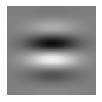

In [6]:
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : [40],
    "spatial_frequencies" : [1/20],
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : [[25, 25]],
    "orientations"        : [np.pi/2],  
    "phases"              : [np.pi/2],
    "relative_sf"         : False
}

gabor_set = GaborSet(**gabor_params)

plt.figure(figsize=(10, 5))
for i, img in enumerate(gabor_set.images()):
    plt.subplot(4, 8, i + 1)
    plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')

In [7]:
stimuli = torch.tensor(gabor_set.images()).float().sum(dim=0)

In [8]:
model = pm.Model()
with model:
    z = pm.Exponential("neuron", lam=Lambda, shape=z_dim)
    x = pm.Normal("stimulus", mu=(gabors.permute(1, 2, 0) @ z), sigma=sigma, observed=stimuli)
    trace = pm.sample(1_000, return_inferencedata=False)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 28 seconds.


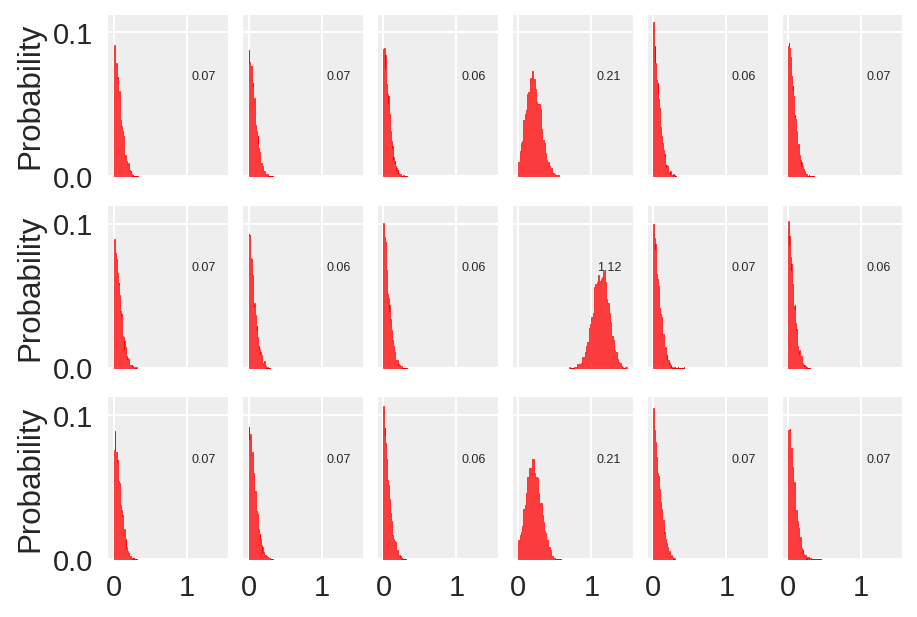

In [9]:

fig, axs = plt.subplots(nrows=3, ncols=6, dpi=150, sharex=True, sharey=True)
for idx, ax in enumerate(axs.ravel()):
    sns.histplot(trace["neuron"][:, idx].ravel(), color="red", stat="probability", element="step", ax=ax)
    ax.text(0.7, 0.6, f"{np.mean(trace['neuron'][:, idx].ravel()):.2f}", fontsize=6, transform=ax.transAxes)


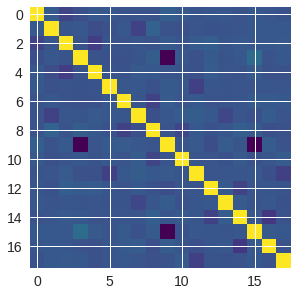

In [10]:
plt.imshow(np.corrcoef(trace["neuron"].T))

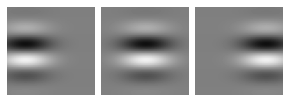

In [11]:
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : [40],
    "spatial_frequencies" : [1/20],
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : [[10, 25], [25, 25], [40, 25]],
    "orientations"        : [np.pi/2],  
    "phases"              : [np.pi/2],
    "relative_sf"         : False
}

gabor_set = GaborSet(**gabor_params)

plt.figure(figsize=(10, 5))
for i, img in enumerate(gabor_set.images()):
    plt.subplot(4, 8, i + 1)
    plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')

In [12]:
stimuli = torch.tensor(gabor_set.images()).float().sum(dim=0)

In [13]:
model = pm.Model()
with model:
    z = pm.Exponential("neuron", lam=Lambda, shape=z_dim)
    x = pm.Normal("stimulus", mu=(gabors.permute(1, 2, 0) @ z), sigma=sigma, observed=stimuli)
    trace = pm.sample(1_000, return_inferencedata=False)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 29 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


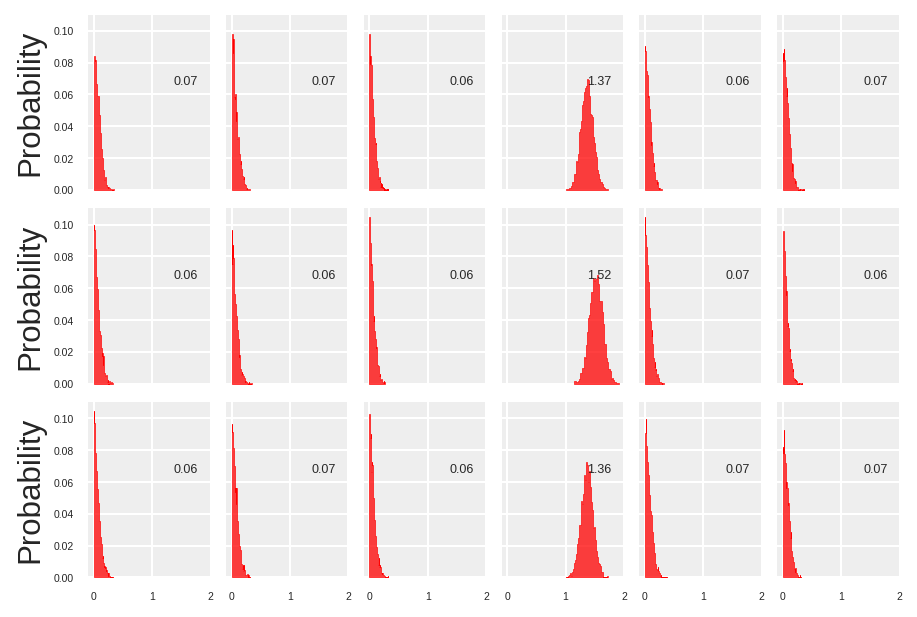

In [14]:

fig, axs = plt.subplots(nrows=3, ncols=6, dpi=150, sharex=True, sharey=True)
for idx, ax in enumerate(axs.ravel()):
    sns.histplot(trace["neuron"][:, idx].ravel(), color="red", stat="probability", element="step", ax=ax)
    # set x axis ticks to be np.arange(0, 3, 0.1)
    # ax.set_xticks(np.arange(0, 3, 0.4))
    # set x and y ticks to have very small font size
    # compute the mean of trace["neuron"][:, idx].ravel() and print it in small font in the top right corner of the plot
    ax.text(0.7, 0.6, f"{np.mean(trace['neuron'][:, idx].ravel()):.2f}", fontsize=6, transform=ax.transAxes)
    # ax.text(0.5, 1.05, f"{np.mean(trace['neuron'][:, idx].ravel()):.2f}", fontsize=6, transform=ax.transAxes)
    ax.tick_params(axis='both', which='major', labelsize=5)

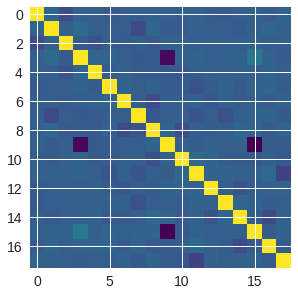

In [15]:
plt.imshow(np.corrcoef(trace["neuron"].T))

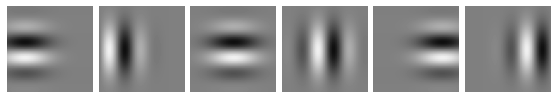

In [16]:
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : [40],
    "spatial_frequencies" : [1/20],
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : [[10, 25], [25, 25], [40, 25]],
    "orientations"        : [np.pi/2, 0],  
    "phases"              : [np.pi/2],
    "relative_sf"         : False
}

gabor_set = GaborSet(**gabor_params)

plt.figure(figsize=(10, 5))
for i, img in enumerate(gabor_set.images()):
    plt.subplot(4, 8, i + 1)
    plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')

In [17]:
a = np.array([1, 2, 3, 4, 5, 6])
print(a[1::2])

[2 4 6]


In [18]:
stimuli = torch.tensor(gabor_set.images()).float()[[1, 2, 5]].sum(dim=0)

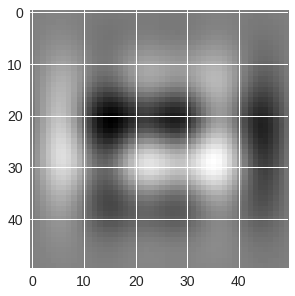

In [19]:
plt.imshow(stimuli, cmap="gray")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 26 seconds.


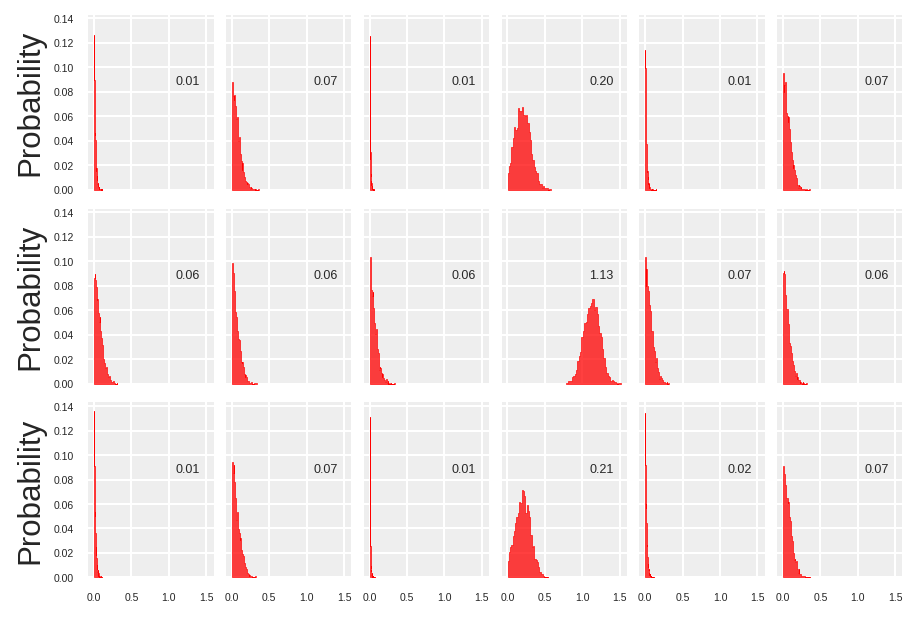

In [20]:
model = pm.Model()
with model:
    z = pm.Exponential("neuron", lam=Lambda, shape=z_dim)
    x = pm.Normal("stimulus", mu=(gabors.permute(1, 2, 0) @ z), sigma=sigma, observed=stimuli)
    trace = pm.sample(1_000, return_inferencedata=False)


fig, axs = plt.subplots(nrows=3, ncols=6, dpi=150, sharex=True, sharey=True)
for idx, ax in enumerate(axs.ravel()):
    sns.histplot(trace["neuron"][:, idx].ravel(), color="red", stat="probability", element="step", ax=ax)
    # set x axis ticks to be np.arange(0, 3, 0.1)
    # ax.set_xticks(np.arange(0, 3, 0.4))
    ax.text(0.7, 0.6, f"{np.mean(trace['neuron'][:, idx].ravel()):.2f}", fontsize=6, transform=ax.transAxes)
    # set x and y ticks to have very small font size
    ax.tick_params(axis='both', which='major', labelsize=5)

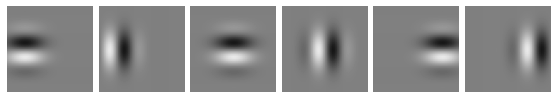

In [21]:
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : [30],
    "spatial_frequencies" : [1/20],
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : [[10, 25], [25, 25], [40, 25]],
    "orientations"        : [np.pi/2, 0],  
    "phases"              : [np.pi/2],
    "relative_sf"         : False
}

gabor_set = GaborSet(**gabor_params)

plt.figure(figsize=(10, 5))
for i, img in enumerate(gabor_set.images()):
    plt.subplot(4, 8, i + 1)
    plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')

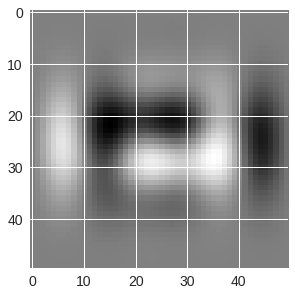

In [22]:
stimuli = torch.tensor(gabor_set.images()).float()[[1, 2, 5]].sum(dim=0)
plt.imshow(stimuli, cmap="gray")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 30 seconds.


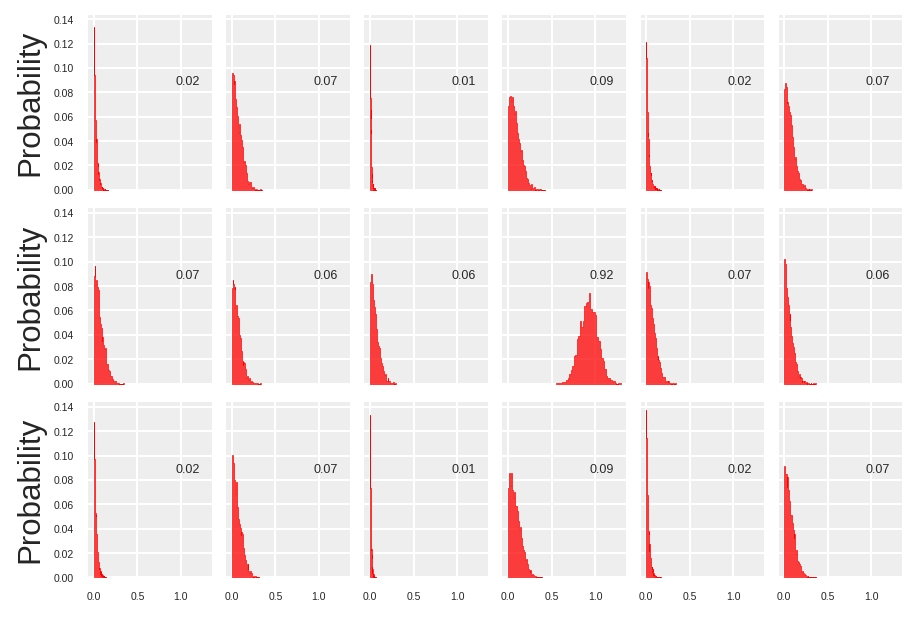

In [23]:
model = pm.Model()
with model:
    z = pm.Exponential("neuron", lam=Lambda, shape=z_dim)
    x = pm.Normal("stimulus", mu=(gabors.permute(1, 2, 0) @ z), sigma=sigma, observed=stimuli)
    trace = pm.sample(1_000, return_inferencedata=False)


fig, axs = plt.subplots(nrows=3, ncols=6, dpi=150, sharex=True, sharey=True)
for idx, ax in enumerate(axs.ravel()):
    sns.histplot(trace["neuron"][:, idx].ravel(), color="red", stat="probability", element="step", ax=ax)
    # set x axis ticks to be np.arange(0, 3, 0.1)
    # ax.set_xticks(np.arange(0, 3, 0.4))
    ax.text(0.7, 0.6, f"{np.mean(trace['neuron'][:, idx].ravel()):.2f}", fontsize=6, transform=ax.transAxes)
    # set x and y ticks to have very small font size
    ax.tick_params(axis='both', which='major', labelsize=5)